In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import astropy.units as u
import bces.bces as BCES

from astropy.table import Table, vstack
from scipy.optimize import curve_fit
from statistics import mean
from scipy.integrate import quad
from sklearn.metrics import r2_score
from collections import Counter
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from astropy.io import fits


In [2]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

In [3]:
labels = ['FSRQ', 'BLL', 'BCU']
colors = ['blue', 'red', 'purple']

In [4]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

def line(x_data,m,c): 
    return m*x_data + c 

In [5]:
Peaked_MeV_Blazar_Catalog = Table.read(catalog_dir + 'Masked_Peaked_MeV_Blazar_Catalog.fits')
Peaked_MeV_FSRQ, Peaked_MeV_BLL, Peaked_MeV_BCU = mask_catalog_by_class(Peaked_MeV_Blazar_Catalog, 'Class')
Masked_Peaked_all = [Peaked_MeV_FSRQ, Peaked_MeV_BLL, Peaked_MeV_BCU]

Transition_MeV_Blazar_Catalog = Table.read(catalog_dir + 'Masked_Transition_MeV_Blazar_Catalog.fits')
Transition_MeV_FSRQ, Transition_MeV_BLL, Transition_MeV_BCU = mask_catalog_by_class(Transition_MeV_Blazar_Catalog, 'Class')
Masked_Transition_all = [Transition_MeV_FSRQ, Transition_MeV_BLL, Transition_MeV_BCU]

Masked_MeV_Blazar_Catalog = Table.read(catalog_dir + 'MeV_Blazars_Sample_Catalog.fits')
Masked_MeV_FSRQ, Masked_MeV_BLL, Masked_MeV_BCU = mask_catalog_by_class(Masked_MeV_Blazar_Catalog, 'Class')
Masked_Blazars_all = [Masked_MeV_FSRQ, Masked_MeV_BLL, Masked_MeV_BCU]

Firm_MeV_Blazar_Catalog = Table.read(catalog_dir + 'Firm_MeV_Blazar_Catalog.fits')
Firm_MeV_FSRQ, Firm_MeV_BLL, Firm_MeV_BCU = mask_catalog_by_class(Firm_MeV_Blazar_Catalog, 'Fermi Type')
Firm_Match_all = [Firm_MeV_FSRQ, Firm_MeV_BLL, Firm_MeV_BCU]

In [13]:
print([x for x in Firm_MeV_Blazar_Catalog['Fermi Counterpart Name'] if x not in Masked_MeV_Blazar_Catalog['Name']])

['B3 0133+388', 'PG 1553+113', 'PMN J2010-2524']


[-2.40626182  6.88238224]
[0.20610257 0.52954245]
-0.8089231876302418 -11.67506954193588 3.916581066835127e-41 13.432189442482768


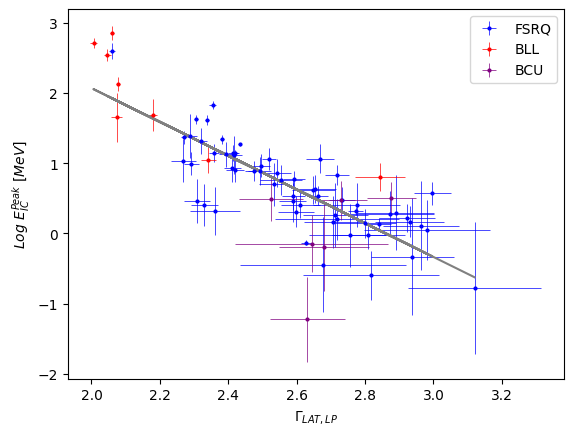

In [6]:
IC_peak_energy_log_all = np.array([np.log10(float(x)) for x in Peaked_MeV_Blazar_Catalog['IC_Peak_Energy'].tolist()])
LAT_LP_gamma_all = np.array(Peaked_MeV_Blazar_Catalog['LAT_LP_Index'].tolist())

for i in range(len(Masked_Peaked_all)):

    LAT_gammas = Masked_Peaked_all[i]['LAT_LP_Index'].tolist()
    LAT_gammas_err = Masked_Peaked_all[i]['LAT_LP_Index_err'].tolist()

    IC_peak_energy = [float(x) for x in Masked_Peaked_all[i]['IC_Peak_Energy'].tolist()]
    IC_peak_energy_log = [np.log10(float(x)) for x in IC_peak_energy]
    IC_peak_energy_err = [(float(x)) for x in Masked_Peaked_all[i]['IC_Peak_Energy_err'].tolist()]
    IC_peak_energy_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(IC_peak_energy_err, IC_peak_energy)]

    plt.errorbar(LAT_gammas,IC_peak_energy_log,xerr=LAT_gammas_err,yerr=IC_peak_energy_err_log,fmt='o',markersize=2,elinewidth=0.5,color=colors[i],label=labels[i])
    plt.xlabel(r'$\Gamma_{LAT,LP}$')
    plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
    plt.legend()

popt,pcov = curve_fit(line,LAT_LP_gamma_all,IC_peak_energy_log_all, p0=[2,4])
print(popt)
perr = np.sqrt(np.diag(pcov))
print(perr)
E_peak_LP_slope = popt[0]
E_peak_LP_intercept = popt[1]

r = np.corrcoef(LAT_LP_gamma_all, IC_peak_energy_log_all)[0,1]
t = r * ((len(IC_peak_energy_log_all) - 2) / (1 - r**2))**0.5
p = 2 * (1 - stats.t.cdf(abs(t), df=len(IC_peak_energy_log_all)-2))

log_p = stats.t.logsf(abs(t), df=len(IC_peak_energy_log_all)-2) + np.log(2)
sigma = norm.isf((10**log_p)/2)

print(r, t, 10**log_p,sigma)

plt.plot(LAT_LP_gamma_all, line(LAT_LP_gamma_all,*popt), color = 'grey', linestyle = '-')

BCES (Y|X): slope = -2.677 ± 0.250, intercept = 7.576 ± 0.634


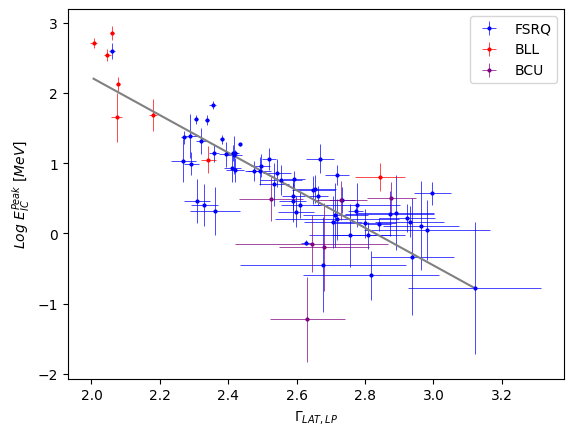

In [7]:
# Flatten arrays
LAT_LP_gamma_all = np.array(Peaked_MeV_Blazar_Catalog['LAT_LP_Index'].tolist(), dtype=float)
LAT_LP_gamma_err_all = np.array(Peaked_MeV_Blazar_Catalog['LAT_LP_Index_err'].tolist(), dtype=float)

IC_peak_energy_all = np.array(Peaked_MeV_Blazar_Catalog['IC_Peak_Energy'].tolist(), dtype=float)
IC_peak_energy_log_all = np.log10(IC_peak_energy_all)
IC_peak_energy_err_all = np.array(Peaked_MeV_Blazar_Catalog['IC_Peak_Energy_err'].tolist(), dtype=float)
IC_peak_energy_err_log_all = np.abs((1 / np.log(10)) * (IC_peak_energy_err_all / IC_peak_energy_all))

# Plot individual subsets
for i in range(len(Masked_Peaked_all)):
    LAT_gammas = np.array(Masked_Peaked_all[i]['LAT_LP_Index'].tolist(), dtype=float)
    LAT_gammas_err = np.array(Masked_Peaked_all[i]['LAT_LP_Index_err'].tolist(), dtype=float)
    IC_peak_energy = np.array(Masked_Peaked_all[i]['IC_Peak_Energy'].tolist(), dtype=float)
    IC_peak_energy_err = np.array(Masked_Peaked_all[i]['IC_Peak_Energy_err'].tolist(), dtype=float)
    IC_peak_energy_log = np.log10(IC_peak_energy)
    IC_peak_energy_err_log = np.abs((1 / np.log(10)) * (IC_peak_energy_err / IC_peak_energy))

    plt.errorbar(LAT_gammas, IC_peak_energy_log, xerr=LAT_gammas_err, yerr=IC_peak_energy_err_log, fmt='o', markersize=2, elinewidth=0.5, color=colors[i], label=labels[i])

plt.xlabel(r'$\Gamma_{LAT,LP}$')
plt.ylabel(r'$Log$ $E^{Peak}_{IC}$ $[MeV]$')
plt.legend()

# --- BCES Y|X regression ---
cov = np.zeros_like(LAT_LP_gamma_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(LAT_LP_gamma_all, LAT_LP_gamma_err_all, IC_peak_energy_log_all, IC_peak_energy_err_log_all, cov)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(LAT_LP_gamma_all), max(LAT_LP_gamma_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')

plt.savefig(outdir + 'BCES_Linear_Regression_E_Gamma.png',dpi=300,bbox_inches='tight')

plt.show()


0.7580347038983622 9.862001724240807 5.329070518200751e-15
[ 0.47334755 -1.84075881]
[0.04799711 0.23358971]
0.7277375065770663 6.366389703812089 2.25701690004243e-07
[ 0.55423594 -2.38355649]
[0.08705656 0.45770953]


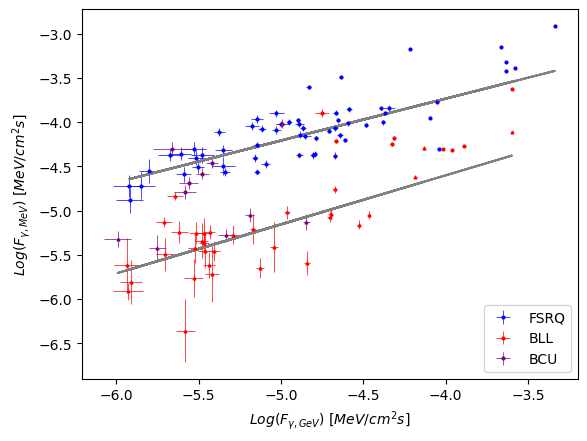

In [8]:
Peaked_MeV_Flux_log_all = []
Peaked_GeV_Flux_log_all = []

for i in range(len(Masked_Peaked_all)):
    GeV_Flux = Masked_Peaked_all[i]['GeV_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Masked_Peaked_all[i]['GeV_Flux'].tolist()]
    GeV_Flux_err = Masked_Peaked_all[i]['GeV_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    MeV_Flux_all = Masked_Peaked_all[i]['MeV_LP_Flux'].tolist()
            
    MeV_Flux_err_all = Masked_Peaked_all[i]['MeV_LP_Flux_err'].tolist()

    MeV_Flux_log = [np.log10(x) for x in MeV_Flux_all]
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err_all, MeV_Flux_all)]
    Peaked_MeV_Flux_log_all.append(MeV_Flux_log)
    
    Peaked_GeV_Flux_log_all.append(GeV_Flux_log)

    plt.errorbar(GeV_Flux_log,MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=MeV_Flux_err_log,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')

Peaked_MeV_Flux_log_all = np.array(Peaked_MeV_Flux_log_all[0] + Peaked_MeV_Flux_log_all[1] + Peaked_MeV_Flux_log_all[2])
Peaked_GeV_Flux_log_all = np.array(Peaked_GeV_Flux_log_all[0] + Peaked_GeV_Flux_log_all[1] + Peaked_GeV_Flux_log_all[2])

#plt.axhline(y=np.log10(energy_flux_sensitivity),linestyle='--',color='grey', label='GRAMS Balloon Sensitivity')
r = np.corrcoef(Peaked_GeV_Flux_log_all, Peaked_MeV_Flux_log_all)[0,1]
t = r * ((len(Peaked_GeV_Flux_log_all) - 2) / (1 - r**2))**0.5
p = 2 * (1 - stats.t.cdf(abs(t), df=len(Peaked_GeV_Flux_log_all)-2))
print(r,t,p)

popt1,pcov1 = curve_fit(line,Peaked_GeV_Flux_log_all,Peaked_MeV_Flux_log_all, p0=[-6, -5.5])
plt.plot(Peaked_GeV_Flux_log_all, line(Peaked_GeV_Flux_log_all,*popt1), color = 'grey', linestyle = '-')
print(popt1)
print(np.sqrt(np.diag(pcov1)))

Transition_MeV_Flux_log_all = []
Transition_GeV_Flux_log_all = []

for i in range(len(Masked_Transition_all)):
    GeV_Flux = Masked_Transition_all[i]['GeV_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Masked_Transition_all[i]['GeV_Flux'].tolist()]
    GeV_Flux_err = Masked_Transition_all[i]['GeV_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    MeV_Flux_all  = Masked_Transition_all[i]['MeV_BPL_Flux'].tolist()
    MeV_Flux_err_all = Masked_Transition_all[i]['MeV_BPL_Flux_err'].tolist()

    MeV_Flux_log = [np.log10(x) for x in MeV_Flux_all]
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err_all, MeV_Flux_all)]
    MeV_Flux_err_log = [0 if x >= 10 else x for x in MeV_Flux_err_log]
    Transition_MeV_Flux_log_all.append(MeV_Flux_log)
    Transition_GeV_Flux_log_all.append(GeV_Flux_log)

    plt.errorbar(GeV_Flux_log,MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=MeV_Flux_err_log,fmt='^',markersize=2,color=colors[i],elinewidth=0.5)

Transition_MeV_Flux_log_all = np.array(Transition_MeV_Flux_log_all[0] + Transition_MeV_Flux_log_all[1] + Transition_MeV_Flux_log_all[2])
Transition_GeV_Flux_log_all = np.array(Transition_GeV_Flux_log_all[0] + Transition_GeV_Flux_log_all[1] + Transition_GeV_Flux_log_all[2])


r = np.corrcoef(Transition_GeV_Flux_log_all, Transition_MeV_Flux_log_all)[0,1]
t = r * ((len(Transition_GeV_Flux_log_all) - 2) / (1 - r**2))**0.5
p = 2 * (1 - stats.t.cdf(abs(t), df=len(Transition_GeV_Flux_log_all)-2))
print(r,t,p)

popt2,pcov2 = curve_fit(line,Transition_GeV_Flux_log_all,Transition_MeV_Flux_log_all, p0=[-6, -5.5])
print(popt2)
print(np.sqrt(np.diag(pcov2)))
plt.plot(Transition_GeV_Flux_log_all, line(Transition_GeV_Flux_log_all,*popt2), color = 'grey', linestyle = '-')
plt.legend(loc='lower right')

plt.savefig(outdir + 'All_blazar_MeV_Flux_relation_final.png', bbox_inches='tight', dpi=300)

Peaked BCES (Y|X): slope = 0.475 ± 0.056, intercept = -1.832 ± 0.287
Transition BCES (Y|X): slope = 0.557 ± 0.083, intercept = -2.367 ± 0.428


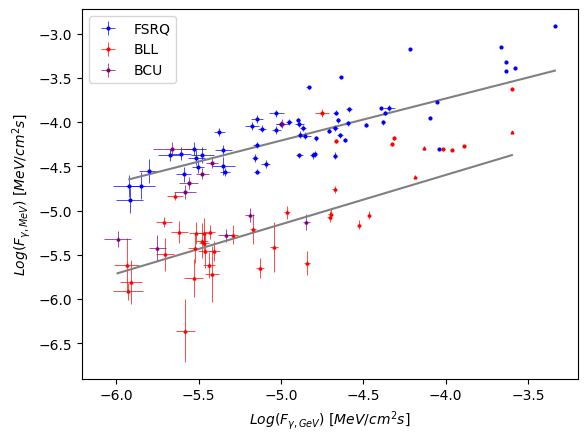

In [9]:
Peaked_MeV_Flux_log_all = []
Peaked_GeV_Flux_log_all = []
Peaked_MeV_Flux_err_log_all = []
Peaked_GeV_Flux_err_log_all = []

for i in range(len(Masked_Peaked_all)):
    GeV_Flux = Masked_Peaked_all[i]['GeV_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Masked_Peaked_all[i]['GeV_Flux'].tolist()]
    GeV_Flux_err = Masked_Peaked_all[i]['GeV_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    MeV_Flux_all = Masked_Peaked_all[i]['MeV_LP_Flux'].tolist()
            
    MeV_Flux_err_all = Masked_Peaked_all[i]['MeV_LP_Flux_err'].tolist()

    MeV_Flux_log = [np.log10(x) for x in MeV_Flux_all]
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err_all, MeV_Flux_all)]
    Peaked_MeV_Flux_log_all.append(MeV_Flux_log)
    
    Peaked_GeV_Flux_log_all.append(GeV_Flux_log)
    Peaked_MeV_Flux_err_log_all.append(MeV_Flux_err_log)
    Peaked_GeV_Flux_err_log_all.append(GeV_Flux_err_log)

    plt.errorbar(GeV_Flux_log,MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=MeV_Flux_err_log,fmt='o',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')
    plt.legend()

Peaked_MeV_Flux_log_all = np.array(Peaked_MeV_Flux_log_all[0] + Peaked_MeV_Flux_log_all[1] + Peaked_MeV_Flux_log_all[2])
Peaked_GeV_Flux_log_all = np.array(Peaked_GeV_Flux_log_all[0] + Peaked_GeV_Flux_log_all[1] + Peaked_GeV_Flux_log_all[2])
Peaked_MeV_Flux_err_log_all = np.array(Peaked_MeV_Flux_err_log_all[0] + Peaked_MeV_Flux_err_log_all[1] + Peaked_MeV_Flux_err_log_all[2])
Peaked_GeV_Flux_err_log_all = np.array(Peaked_GeV_Flux_err_log_all[0] + Peaked_GeV_Flux_err_log_all[1] + Peaked_GeV_Flux_err_log_all[2])

cov = np.zeros_like(Peaked_GeV_Flux_log_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(Peaked_GeV_Flux_log_all, Peaked_GeV_Flux_err_log_all, Peaked_MeV_Flux_log_all, Peaked_MeV_Flux_err_log_all, cov)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"Peaked BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(Peaked_GeV_Flux_log_all), max(Peaked_GeV_Flux_log_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')

Transition_MeV_Flux_log_all = []
Transition_GeV_Flux_log_all = []
Transition_MeV_Flux_err_log_all = []
Transition_GeV_Flux_err_log_all = []

for i in range(len(Masked_Transition_all)):
    GeV_Flux = Masked_Transition_all[i]['GeV_Flux'].tolist()
    GeV_Flux_log = [np.log10(x) for x in Masked_Transition_all[i]['GeV_Flux'].tolist()]
    GeV_Flux_err = Masked_Transition_all[i]['GeV_Flux_err'].tolist()
    GeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(GeV_Flux_err, GeV_Flux)]

    MeV_Flux_all = Masked_Transition_all[i]['MeV_BPL_Flux'].tolist()
            
    MeV_Flux_err_all = Masked_Transition_all[i]['MeV_BPL_Flux_err'].tolist()

    MeV_Flux_log = [np.log10(x) for x in MeV_Flux_all]
    MeV_Flux_err_log = [abs((1/np.log(10)) * (x/y)) for x,y in zip(MeV_Flux_err_all, MeV_Flux_all)]
    Transition_MeV_Flux_log_all.append(MeV_Flux_log)
    
    Transition_GeV_Flux_log_all.append(GeV_Flux_log)
    Transition_MeV_Flux_err_log_all.append(MeV_Flux_err_log)
    Transition_GeV_Flux_err_log_all.append(GeV_Flux_err_log)

    plt.errorbar(GeV_Flux_log,MeV_Flux_log,xerr=GeV_Flux_err_log,yerr=MeV_Flux_err_log,fmt='^',markersize=2,color=colors[i],label=labels[i],elinewidth=0.5)
    plt.xlabel(r'$Log(F_{\gamma, GeV})$ $[MeV/cm^{2} s]$')
    plt.ylabel(r'$Log(F_{\gamma, MeV})$ $[MeV/cm^{2} s]$')


Transition_MeV_Flux_log_all = np.array(Transition_MeV_Flux_log_all[0] + Transition_MeV_Flux_log_all[1] + Transition_MeV_Flux_log_all[2])
Transition_GeV_Flux_log_all = np.array(Transition_GeV_Flux_log_all[0] + Transition_GeV_Flux_log_all[1] + Transition_GeV_Flux_log_all[2])
Transition_MeV_Flux_err_log_all = np.array(Transition_MeV_Flux_err_log_all[0] + Transition_MeV_Flux_err_log_all[1] + Transition_MeV_Flux_err_log_all[2])
Transition_GeV_Flux_err_log_all = np.array(Transition_GeV_Flux_err_log_all[0] + Transition_GeV_Flux_err_log_all[1] + Transition_GeV_Flux_err_log_all[2])

cov = np.zeros_like(Transition_GeV_Flux_log_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(Transition_GeV_Flux_log_all, Transition_GeV_Flux_err_log_all, Transition_MeV_Flux_log_all, Transition_MeV_Flux_err_log_all, cov)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"Transition BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(Transition_GeV_Flux_log_all), max(Transition_GeV_Flux_log_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')

plt.savefig(outdir + 'BCES_MeV_GeV_Flux_reg.png', dpi=300, bbox_inches='tight')
plt.show()

55
4
[  0.43969774 -12.00207695]
[0.07079778 3.36825246]
0.6352867872811585 6.210614005802438 6.484616488222628e-08 5.4048955636722695


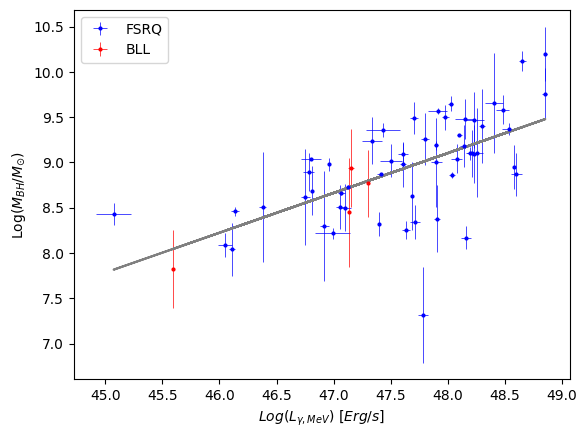

In [10]:
masked_lum_mass = [(float(b), float(a)) for a, b in zip(Peaked_MeV_Blazar_Catalog['SMBH_Mass'].tolist(), Peaked_MeV_Blazar_Catalog['MeV_Luminosity'].tolist()) if a != 'None' and b != 'None']
masked_luminosity_all, masked_mass_all = zip(*masked_lum_mass)

masked_luminosity_all = np.array(list(masked_luminosity_all))
masked_mass_all = np.array(list(masked_mass_all))
#print(masked_luminosity_all)
#print(masked_mass_all)

for i in range(len(Masked_Peaked_all)):
    Mass = Masked_Peaked_all[i]['SMBH_Mass'].tolist()
    Mass_err = Masked_Peaked_all[i]['SMBH_Mass_Err'].tolist()
    Luminosity = Masked_Peaked_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Peaked_all[i]['MeV_Luminosity_err'].tolist()

    masked_results = [(float(c), float(d), float(a), float(b)) for a, b, c, d in zip(Mass, Mass_err, Luminosity, Luminosity_err) if a != 'None' and c != 'None']

    if len(masked_results) != 0:
        masked_luminosity, masked_luminosity_err, masked_mass, masked_mass_err = zip(*masked_results)

        masked_luminosity = list(masked_luminosity)
        masked_luminosity_err = list(masked_luminosity_err)
        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)

        plt.errorbar(masked_luminosity, masked_mass, xerr=masked_luminosity_err, yerr=masked_mass_err, fmt='o', markersize=2, color=colors[i], label=labels[i], elinewidth=0.5)
        print(len(masked_luminosity))
        plt.xlabel(r'$Log(L_{\gamma, MeV})$ $[Erg/s]$')
        plt.ylabel(r'Log($M_{BH}$/$M_{\odot}$)')
        plt.legend()

popt, pcov = curve_fit(line, masked_luminosity_all, masked_mass_all, p0=[1, 8])
plt.plot(masked_luminosity_all, line(masked_luminosity_all, *popt), color='grey', linestyle='-')
print(popt)
print(np.sqrt(np.diag(pcov)))
r = np.corrcoef(masked_luminosity_all, masked_mass_all)[0,1]
t = r * ((len(masked_luminosity_all) - 2) / (1 - r**2))**0.5
p = 2 * (1 - stats.t.cdf(abs(t), df=len(masked_luminosity_all)-2))
sigma = norm.isf(p/2)
print(r, t, p, sigma)

Peaked_Luminosity_slope = (1 / popt[0])
Peaked_Luminosity_intercept = (-popt[1] / popt[0])

plt.savefig(outdir + 'BH_Luminosity_correlation2.png', bbox_inches='tight',dpi=300)

55
4
BCES (Y|X): slope = 0.442 ± 0.067, intercept = -12.103 ± 3.160


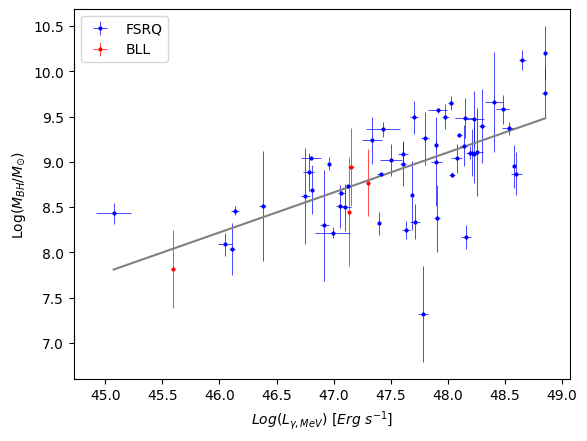

In [11]:
masked_lum_mass = [(float(a), float(b), float(c), float(d)) for a, b, c, d in zip(Peaked_MeV_Blazar_Catalog['SMBH_Mass'].tolist(), Peaked_MeV_Blazar_Catalog['SMBH_Mass_Err'].tolist(), Peaked_MeV_Blazar_Catalog['MeV_Luminosity'].tolist(), Peaked_MeV_Blazar_Catalog['MeV_Luminosity_err'].tolist()) if a != 'None' and b != 'None']
masked_mass_all, masked_mass_err_all, masked_luminosity_all, masked_luminosity_err_all = zip(*masked_lum_mass)

masked_luminosity_all = np.array(list(masked_luminosity_all))
masked_luminosity_err_all = np.array(list(masked_luminosity_err_all))
masked_mass_all = np.array(list(masked_mass_all))
masked_mass_err_all = np.array(list(masked_mass_err_all))
#print(masked_luminosity_all)
#print(masked_mass_all)

for i in range(len(Masked_Peaked_all)):
    Mass = Masked_Peaked_all[i]['SMBH_Mass'].tolist()
    Mass_err = Masked_Peaked_all[i]['SMBH_Mass_Err'].tolist()
    Luminosity = Masked_Peaked_all[i]['MeV_Luminosity'].tolist()
    Luminosity_err = Masked_Peaked_all[i]['MeV_Luminosity_err'].tolist()

    masked_results = [(float(c), float(d), float(a), float(b)) for a, b, c, d in zip(Mass, Mass_err, Luminosity, Luminosity_err) if a != 'None' and c != 'None']

    if len(masked_results) != 0:
        masked_luminosity, masked_luminosity_err, masked_mass, masked_mass_err = zip(*masked_results)

        masked_luminosity = list(masked_luminosity)
        masked_luminosity_err = list(masked_luminosity_err)
        masked_mass = list(masked_mass)
        masked_mass_err = list(masked_mass_err)

        plt.errorbar(masked_luminosity, masked_mass, xerr=masked_luminosity_err, yerr=masked_mass_err, fmt='o', markersize=2, color=colors[i], label=labels[i], elinewidth=0.5)
        print(len(masked_luminosity))
        plt.xlabel(r'$Log(L_{\gamma, MeV})$ [$Erg$ $s^{-1}$]')
        plt.ylabel(r'Log($M_{BH}$/$M_{\odot}$)')
        plt.legend()
        
# --- BCES Y|X regression ---
cov = np.zeros_like(masked_luminosity_all)  # assuming x and y errors uncorrelated
a, b, aerr, berr, covab = BCES.bces(masked_luminosity_all, masked_luminosity_err_all, masked_mass_all, masked_mass_err_all, cov)

# BCES Y|X results:
slope = a[0]
intercept = b[0]
slope_err = aerr[0]
intercept_err = berr[0]

print(f"BCES (Y|X): slope = {slope:.3f} ± {slope_err:.3f}, intercept = {intercept:.3f} ± {intercept_err:.3f}")

# --- Plot BCES best-fit line ---
x_line = np.linspace(min(masked_luminosity_all), max(masked_luminosity_all), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='grey', linestyle='-')
plt.savefig(outdir + 'BCES_SMBH_mass_lum_reg.png',dpi=300,bbox_inches='tight')